En esta etapa, importaremos las herramientas necesarias para el análisis. Utilizaremos la biblioteca scikit-learn para descargar el dataset directamente a nuestro entorno de manera confiable. Luego, convertiremos estos datos en un formato tabular (DataFrame de pandas) para facilitar su exploración estadística y visual.

--- Primeras 5 filas del dataset (head) ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0.0,setosa
1,4.9,3.0,1.4,0.2,0.0,setosa
2,4.7,3.2,1.3,0.2,0.0,setosa
3,4.6,3.1,1.5,0.2,0.0,setosa
4,5.0,3.6,1.4,0.2,0.0,setosa



--- Información general (info) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    float64
 5   species            150 non-null    object 
dtypes: float64(5), object(1)
memory usage: 7.2+ KB


None


--- Estadísticas descriptivas (describe) ---


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


/tmp/ipykernel_1154/1905089303.py:40: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='species', data=df, palette='viridis')


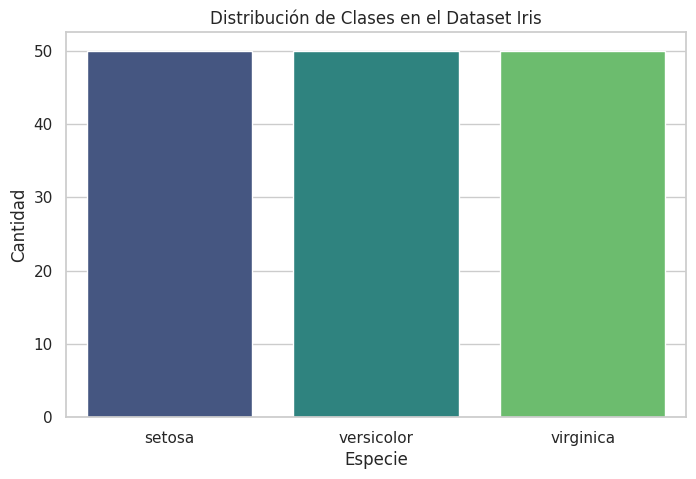

In [6]:
# ==========================================
# 2. CARGA DEL DATASET Y EXPLORACIÓN BÁSICA
# ==========================================

# Importación de librerías base
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Importación del dataset desde scikit-learn
from sklearn.datasets import load_iris

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")

# Cargar los datos
iris = load_iris()

# Crear un DataFrame de pandas
df = pd.DataFrame(data=np.c_[iris['data'], iris['target']],
                  columns=iris['feature_names'] + ['target'])

# Mapear los números del target a los nombres reales de las especies para mayor claridad
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})

# --- Exploración del Dataset ---

print("--- Primeras 5 filas del dataset (head) ---")
display(df.head())

print("\n--- Información general (info) ---")
display(df.info())

print("\n--- Estadísticas descriptivas (describe) ---")
display(df.describe())

# Distribución de clases
plt.figure(figsize=(8, 5))
sns.countplot(x='species', data=df, palette='viridis')
plt.title('Distribución de Clases en el Dataset Iris')
plt.xlabel('Especie')
plt.ylabel('Cantidad')
plt.show()

Preprocesamiento de Datos
Antes de entrenar un modelo, los datos deben ser preparados.

Valores faltantes: Verificaremos si hay celdas vacías. Si las hubiera, podríamos imputarlas (rellenarlas con la media/mediana) o eliminarlas.

Codificación de variables categóricas: Algoritmos como Random Forest requieren datos numéricos. Si tuviéramos variables como "Color" (Rojo, Azul), usaríamos One-Hot Encoding para crear columnas binarias (ej. es_rojo: 1 o 0). En Iris, las medidas ya son numéricas y scikit-learn maneja el target codificado numéricamente.

División del dataset: Separaremos los datos en un conjunto de entrenamiento (para que el modelo aprenda) y uno de prueba (para evaluar su desempeño en datos nunca antes vistos).

In [7]:
# ==========================================
# 3. PREPROCESAMIENTO DE DATOS
# ==========================================

from sklearn.model_selection import train_test_split

# 1. Manejo de valores faltantes
print("--- Verificación de Valores Faltantes ---")
faltantes = df.isnull().sum()
print(faltantes)
# Nota conceptual: Si tuviéramos valores nulos en 'sepal length (cm)',
# podríamos rellenarlos con el promedio usando:
# df['sepal length (cm)'].fillna(df['sepal length (cm)'].mean(), inplace=True)

# 2. Definir variables predictoras (X) y variable objetivo (y)
# Usamos las 4 columnas de medidas como X y el target numérico como y
X = df.drop(['target', 'species'], axis=1)
y = df['target']

# 3. División del Dataset
# Separamos 80% para entrenamiento y 20% para prueba
# random_state asegura que la división sea reproducible
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape[0]} muestras")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} muestras")

--- Verificación de Valores Faltantes ---
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
target               0
species              0
dtype: int64

Tamaño del conjunto de entrenamiento: 120 muestras
Tamaño del conjunto de prueba: 30 muestras


Construcción y Entrenamiento de Modelos
Enfocaremos nuestro esfuerzo en el Random Forest.

Ensemble Learning: Es una técnica que combina las predicciones de múltiples modelos base para mejorar la robustez y generalización.

Conjunto de Árboles y Votación: Random Forest crea un "bosque" de múltiples árboles de decisión. Cada árbol se entrena con una muestra aleatoria de los datos y las características. Al clasificar una nueva flor, cada árbol "vota" por una clase, y el bosque elige la clase con la mayoría de votos.

Hiperparámetros importantes:

n_estimators: La cantidad de árboles en el bosque (usaremos 100).

max_depth: La profundidad máxima de cada árbol. Limitarla ayuda a que el modelo no se vuelva excesivamente complejo.

random_state: Semilla para garantizar que los resultados sean reproducibles.

In [8]:
# ==========================================
# 4. CONSTRUCCIÓN Y ENTRENAMIENTO: RANDOM FOREST
# ==========================================

from sklearn.ensemble import RandomForestClassifier

# Instanciar el modelo con hiperparámetros específicos
rf_model = RandomForestClassifier(
    n_estimators=100,    # Número de árboles en el bosque
    max_depth=4,         # Profundidad máxima para evitar sobreajuste
    random_state=42,     # Semilla de reproducibilidad
    n_jobs=-1            # Usar todos los núcleos del procesador
)

# Entrenar el modelo con los datos de entrenamiento
rf_model.fit(X_train, y_train)

# Generar predicciones sobre el conjunto de prueba
y_pred = rf_model.predict(X_test)
# Generar probabilidades (necesarias luego para la curva ROC)
y_prob = rf_model.predict_proba(X_test)

print("¡Modelo Random Forest entrenado exitosamente y predicciones generadas!")

¡Modelo Random Forest entrenado exitosamente y predicciones generadas!


Evaluación de Modelos
Evaluar un modelo va mucho más allá de simplemente ver si "acertó".

Matriz de Confusión: Una tabla que cruza las predicciones reales con las del modelo.

Verdaderos Positivos/Negativos (TP/TN): El modelo predijo correctamente la clase.

Falsos Positivos (FP - Error Tipo I): El modelo predijo una clase, pero en realidad era otra.

Falsos Negativos (FN - Error Tipo II): El modelo no detectó la clase cuando en realidad sí lo era.

Accuracy: El porcentaje total de aciertos. Es útil en datasets balanceados (como Iris).

Precision: De todas las predicciones positivas que hizo el modelo, ¿cuántas eran correctas? (Ej. En detección de fraude, queremos alta precisión para no bloquear tarjetas de clientes honestos).

Recall: De todos los casos positivos reales, ¿cuántos encontró el modelo? (Ej. En detección de enfermedades graves, queremos un alto recall para no dejar escapar ningún enfermo, aunque haya falsas alarmas).

F1-Score: Es la media armónica entre Precision y Recall, ideal cuando buscamos equilibrio.

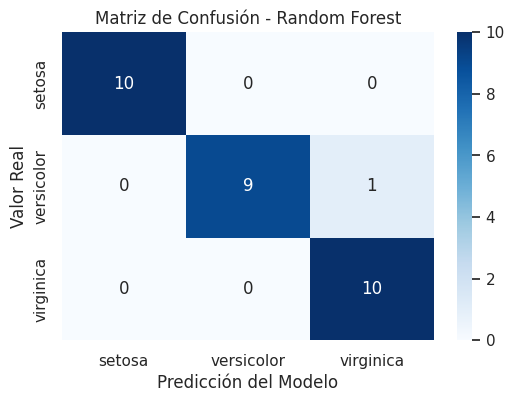

--- Reporte de Clasificación ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

Accuracy general: 0.9667


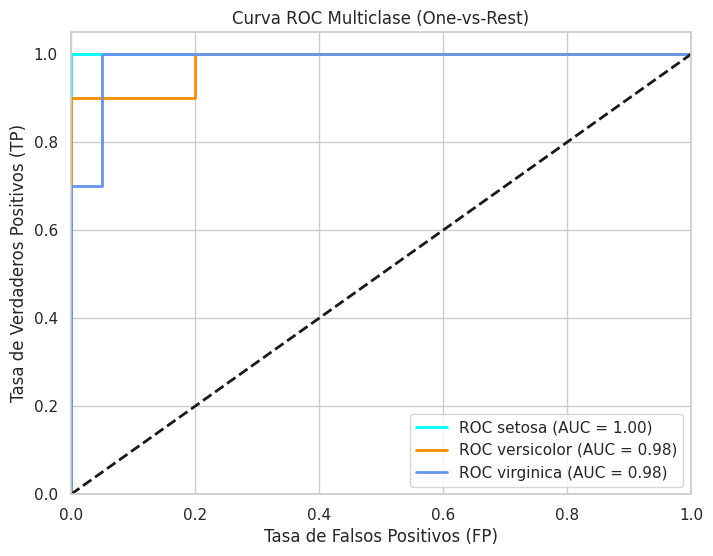

In [9]:
# ==========================================
# 5. EVALUACIÓN DEL MODELO
# ==========================================

from sklearn.metrics import (confusion_matrix, classification_report,
                             accuracy_score, roc_curve, auc)
from sklearn.preprocessing import label_binarize

# 1. Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.title('Matriz de Confusión - Random Forest')
plt.xlabel('Predicción del Modelo')
plt.ylabel('Valor Real')
plt.show()

# 2. Métricas de Clasificación Clásicas
print("--- Reporte de Clasificación ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy general: {acc:.4f}")

# 3. Curva ROC y AUC (Adaptado para Multiclase: One-vs-Rest)
# Binarizamos las etiquetas para calcular la curva ROC por clase
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
n_classes = y_test_bin.shape[1]

plt.figure(figsize=(8, 6))
colores = ['aqua', 'darkorange', 'cornflowerblue']

for i, color in zip(range(n_classes), colores):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'ROC {iris.target_names[i]} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FP)')
plt.ylabel('Tasa de Verdaderos Positivos (TP)')
plt.title('Curva ROC Multiclase (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

Análisis Comparativo


/tmp/ipykernel_1154/243444283.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Característica', data=df_importancias, palette='mako')


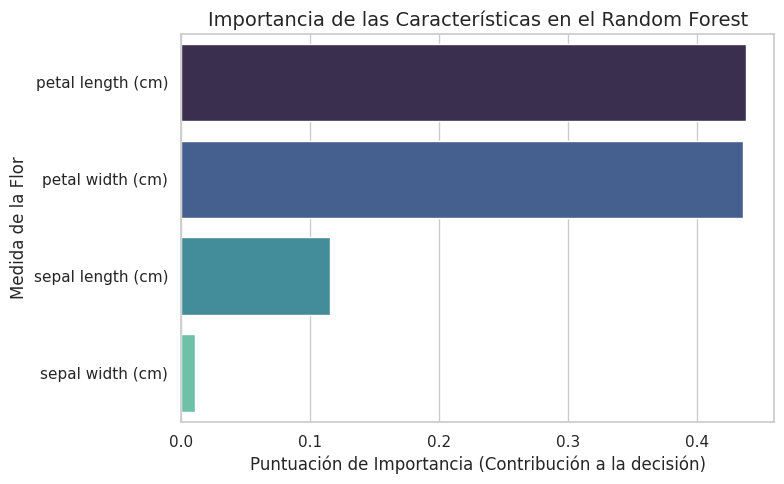

--- Tabla de Importancia de Características ---


,Característica,Importancia
2,petal length (cm),0.437745
3,petal width (cm),0.435857
0,sepal length (cm),0.115645
1,sepal width (cm),0.010754


In [11]:
# ==========================================
# 6. ANÁLISIS DE IMPORTANCIA DE CARACTERÍSTICAS
# ==========================================

# Extraer la importancia calculada por el algoritmo Random Forest
importancias = rf_model.feature_importances_
nombres_caracteristicas = iris.feature_names

# Crear un DataFrame para facilitar la visualización
df_importancias = pd.DataFrame({
    'Característica': nombres_caracteristicas,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Visualizar la importancia
plt.figure(figsize=(8, 5))
sns.barplot(x='Importancia', y='Característica', data=df_importancias, palette='mako')
plt.title('Importancia de las Características en el Random Forest', fontsize=14)
plt.xlabel('Puntuación de Importancia (Contribución a la decisión)', fontsize=12)
plt.ylabel('Medida de la Flor', fontsize=12)
plt.tight_layout()
plt.show()

# Imprimir como tabla
print("--- Tabla de Importancia de Características ---")
display(df_importancias)

Visualizacion del Árbol

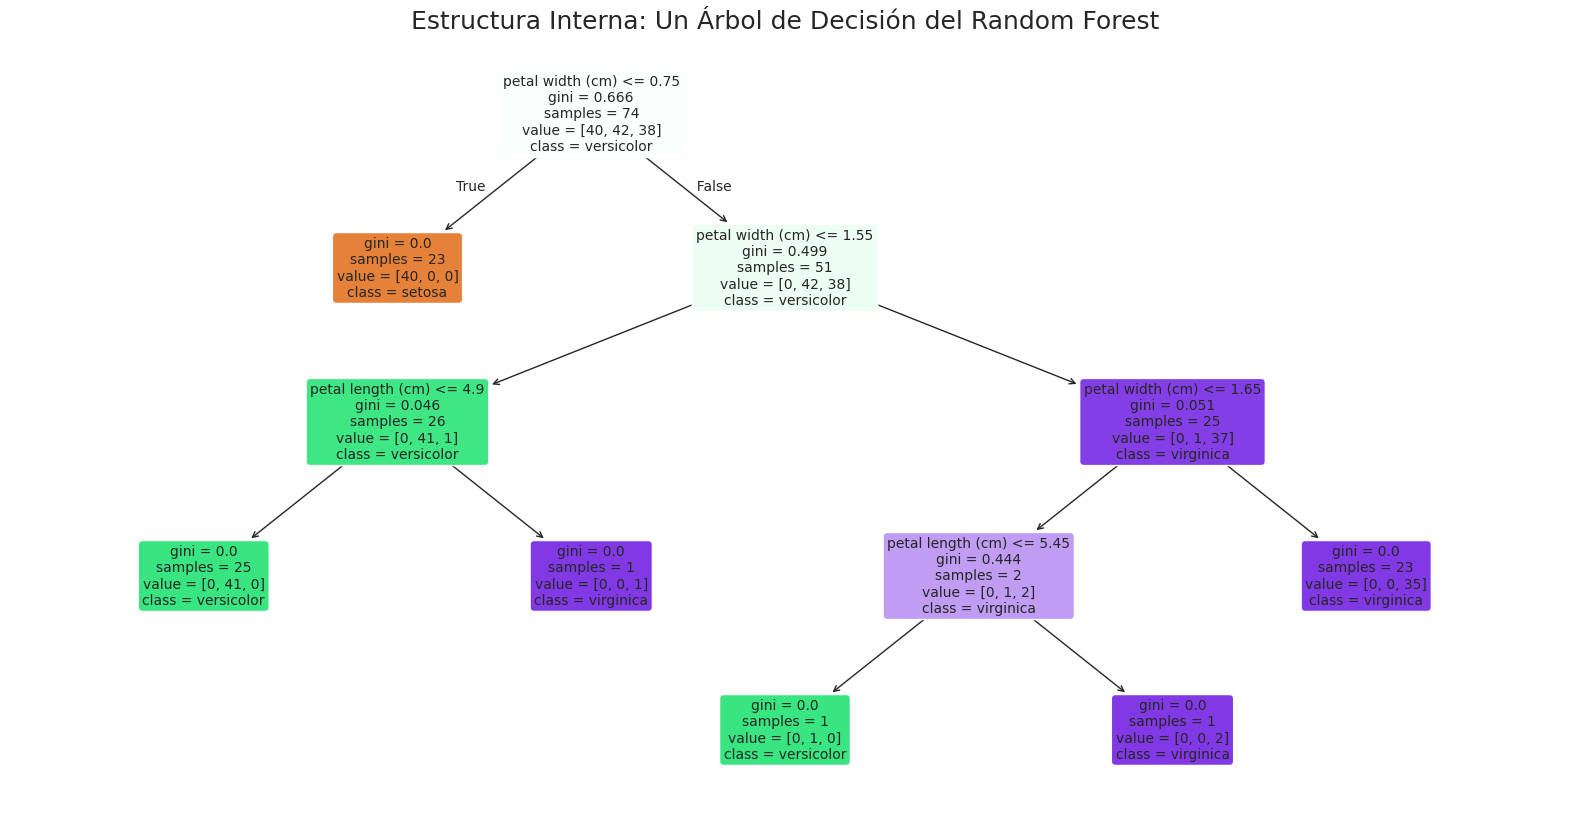

In [12]:
# ==========================================
# EXTRA: VISUALIZACIÓN DE UN ÁRBOL DEL BOSQUE
# ==========================================
from sklearn.tree import plot_tree

# Extraemos el primer árbol (índice 0) de nuestro modelo Random Forest
# Recuerda que nuestro bosque tiene 100 árboles (n_estimators=100)
arbol_ejemplo = rf_model.estimators_[0]

# Configuramos el tamaño de la figura para que sea legible
plt.figure(figsize=(20, 10))

# Dibujamos el árbol
plot_tree(arbol_ejemplo,
          feature_names=iris.feature_names,
          class_names=iris.target_names,
          filled=True,      # Colorea los nodos según la clase predominante
          rounded=True,     # Bordes redondeados para mejor estética
          fontsize=10)      # Tamaño de la letra

plt.title('Estructura Interna: Un Árbol de Decisión del Random Forest', fontsize=18)
plt.show()